# Training a regression model using TensorFlow
> This is a basic tutorial for training a regression model using Tensorflow. It covers:

1- Regression to approximate Sine function using Multilayer Perceptron (MLP)

2- Conversion of the Tensorflow model to Tensorflow Lite (quantization)

Inspired from:
https://github.com/tensorflow/tflite-micro/tree/main/tensorflow/lite/micro/examples/hello_world/



In [1]:
#from google.colab import drive
#drive.mount('/content/gdrive')

In [2]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import math

plt.rcParams['figure.figsize'] = (32, 20)
plt.rcParams['text.usetex'] = True
plt.rc('font', size=15)
plt.style.use('classic')


### Hello world
In this example, our ML regression hypothesis will approximate the sine function.

$$ \tilde{h}(x) = \sin(x) $$



In [3]:
# Seed the RNG to get the same random numbers everytime
np.random.seed(1) # numpy seed
tf.random.set_seed(1) # tensorflow seed

In [4]:
print('Numpy: {}'.format(np.__version__))
print('Tensorflow: {}'.format(tf.__version__))

Numpy: 1.22.4
Tensorflow: 2.12.0


Generate artificial training data through known function i.e. sine

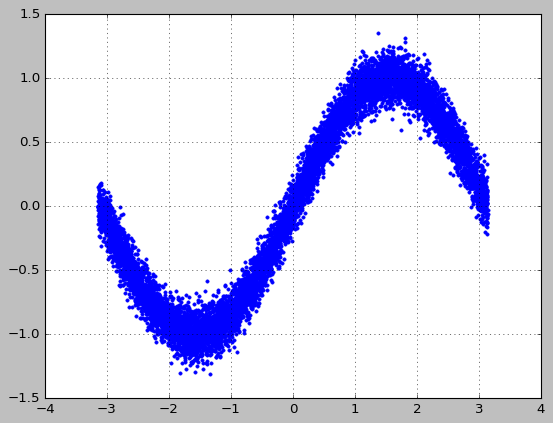

In [5]:
# Generate uniformly distributed RVs in the range [0 2*pi]. 
#X = np.random.uniform(low=0, high=2*math.pi, size=10000).astype(np.float32)

# Generate uniformly distributed RVs in the range [-pi pi]
#This dataset give a better output! Maybe because data is centered around zero?
X = np.random.uniform(low=-math.pi, high=math.pi, size=10000).astype(np.float32)

# Shuffle to break order
np.random.shuffle(X)

# Calculate the labels
y = np.sin(X).astype(np.float32)

# Add a little noise to make it realistic
y += 0.1 * np.random.randn(*y.shape)

# Plot our data
plt.plot(X, y, 'b.')
plt.grid()
plt.show()


Split the data as follows:
    
- Train data: 60%
- Validation data: 20%
- Test data: 20%

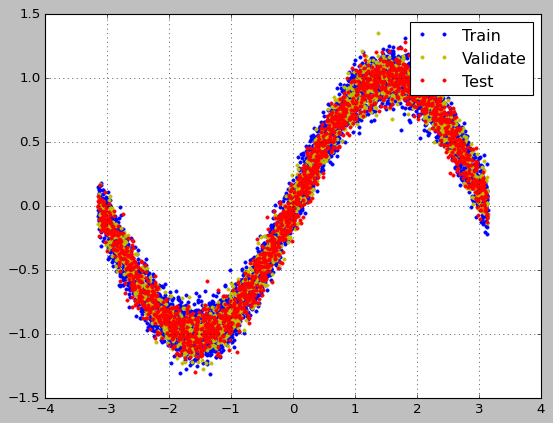

In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.25, random_state=1)

# Plot using different colors:
plt.plot(X_train, y_train, 'b.', label="Train")
plt.plot(X_val, y_val, 'y.', label="Validate")
plt.plot(X_test, y_test, 'r.', label="Test")
plt.legend()
plt.grid()
plt.show()

Our regression model will have three layers: input, hidden and output. The hidden layer has 16 neurons with Relu activation function. To implement this, we use the sequential model in tensorflow-keras. 
We will use Adam optimizer with a learning rate of 1.5. Mean Squared Error (MSE) will be the loss and Mean Absolute Error (MAE) will also be plotted to see the training progress. 

In [7]:
model1 = tf.keras.Sequential(name='sine_mlp')
model1.add(tf.keras.layers.Dense(16, activation='relu', input_shape=(1, )))
#model1.add(tf.keras.layers.Dense(16, activation='sigmoid', input_shape=(1, )))
model1.add(tf.keras.layers.Dense(1))

model1.summary()

Model: "sine_mlp"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 16)                32        
                                                                 
 dense_1 (Dense)             (None, 1)                 17        
                                                                 
Total params: 49
Trainable params: 49
Non-trainable params: 0
_________________________________________________________________


In [8]:
#model.compile(optimizer='adam', loss='mse', metrics=['accuracy', 'mae'])
optimizer = tf.keras.optimizers.Adam(lr=1.5)
model1.compile(optimizer=optimizer, loss='mse', metrics=['accuracy', 'mae'])

Let's train it with a batch size of 15 for 50 epochs. 

In [9]:
history = model1.fit(X_train, y_train, epochs=50, batch_size=15, validation_data=(X_val, y_val), verbose=True)

Epoch 1/50
400/400 [==============================] - 7s 5ms/step - loss: 0.2376 - accuracy: 0.0000e+00 - mae: 0.4195 - val_loss: 0.1711 - val_accuracy: 0.0000e+00 - val_mae: 0.3565
Epoch 2/50
400/400 [==============================] - 1s 3ms/step - loss: 0.1651 - accuracy: 0.0000e+00 - mae: 0.3500 - val_loss: 0.1538 - val_accuracy: 0.0000e+00 - val_mae: 0.3374
Epoch 3/50
400/400 [==============================] - 1s 3ms/step - loss: 0.1444 - accuracy: 0.0000e+00 - mae: 0.3260 - val_loss: 0.1284 - val_accuracy: 0.0000e+00 - val_mae: 0.3060
Epoch 4/50
400/400 [==============================] - 1s 3ms/step - loss: 0.1157 - accuracy: 0.0000e+00 - mae: 0.2884 - val_loss: 0.0987 - val_accuracy: 0.0000e+00 - val_mae: 0.2649
Epoch 5/50
400/400 [==============================] - 1s 3ms/step - loss: 0.0852 - accuracy: 0.0000e+00 - mae: 0.2431 - val_loss: 0.0696 - val_accuracy: 0.0000e+00 - val_mae: 0.2145
Epoch 6/50
400/400 [==============================] - 1s 3ms/step - loss: 0.0595 - accurac

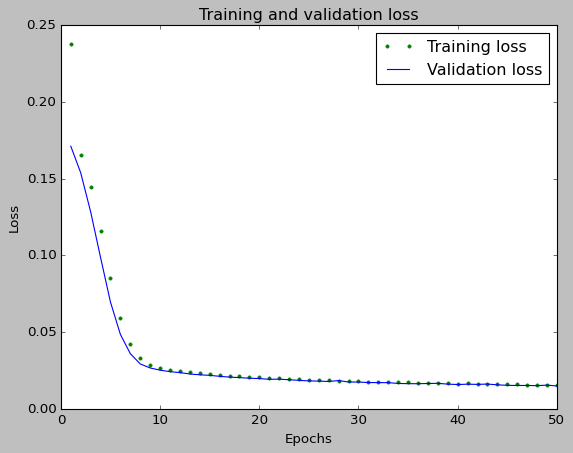

In [10]:
# Plot the training and validation losses.
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1, len(loss) + 1)

plt.plot(epochs, loss, 'g.', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()


63/63 [==============================] - 0s 4ms/step


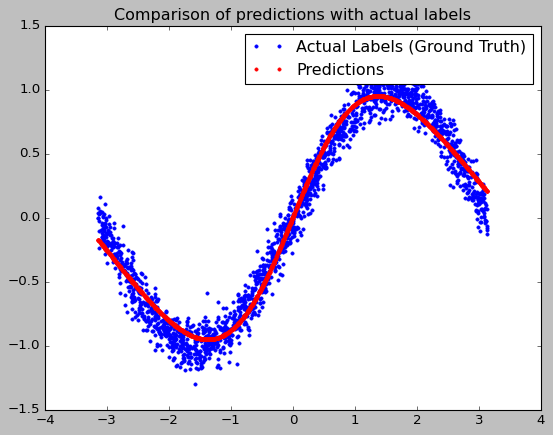

In [11]:
# Evaluate the model on Test set
loss = model1.evaluate(X_test, y_test)
predictions = model1.predict(X_test)

# Visualize the predictions against labels
plt.clf()
plt.title('Comparison of predictions with actual labels')
plt.plot(X_test, y_test, 'b.', label='Actual Labels (Ground Truth)')
plt.plot(X_test, predictions, 'r.', label='Predictions')
plt.legend()
plt.show()

Let's try a model with more hidden layers (deep) but with fewer neurons per layer

In [ ]:
model2 = tf.keras.Sequential(name='sine_mlp_deep')

# Input to the first layer is a scalar which feeds the next hidden layer with 4 neurons 
model2.add(tf.keras.layers.Dense(4, activation='relu', input_shape=(1,)))

# The second layer has 4 neurons and will learn more complex features than one hidden layer alone
model2.add(tf.keras.layers.Dense(4, activation='relu'))

# Final layer outputs a scalar
model2.add(tf.keras.layers.Dense(1))

# Compile the model and set appropriate training parameters
optimizer = tf.keras.optimizers.SGD(learning_rate=0.01)
#optimizer = tf.keras.optimizers.Adam(lr=0.0001)
model2.compile(optimizer=optimizer, loss='mse', metrics=['accuracy', 'mae'])

model2.summary()

Model: "sine_mlp_deep"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_91 (Dense)            (None, 4)                 8         
                                                                 
 dense_92 (Dense)            (None, 4)                 20        
                                                                 
 dense_93 (Dense)            (None, 1)                 5         
                                                                 
Total params: 33
Trainable params: 33
Non-trainable params: 0
_________________________________________________________________


In [ ]:
history = model2.fit(X_train, y_train, epochs=50, batch_size=64,
                    validation_data=(X_val, y_val), verbose=True)

Epoch 1/50
94/94 [==============================] - 0s 3ms/step - loss: 0.0118 - accuracy: 0.0000e+00 - mae: 0.0866 - val_loss: 0.0112 - val_accuracy: 0.0000e+00 - val_mae: 0.0849
Epoch 2/50
94/94 [==============================] - 0s 3ms/step - loss: 0.0118 - accuracy: 0.0000e+00 - mae: 0.0864 - val_loss: 0.0111 - val_accuracy: 0.0000e+00 - val_mae: 0.0844
Epoch 3/50
94/94 [==============================] - 1s 11ms/step - loss: 0.0118 - accuracy: 0.0000e+00 - mae: 0.0863 - val_loss: 0.0111 - val_accuracy: 0.0000e+00 - val_mae: 0.0845
Epoch 4/50
94/94 [==============================] - 0s 3ms/step - loss: 0.0117 - accuracy: 0.0000e+00 - mae: 0.0862 - val_loss: 0.0111 - val_accuracy: 0.0000e+00 - val_mae: 0.0842
Epoch 5/50
94/94 [==============================] - 1s 8ms/step - loss: 0.0117 - accuracy: 0.0000e+00 - mae: 0.0862 - val_loss: 0.0110 - val_accuracy: 0.0000e+00 - val_mae: 0.0841
Epoch 6/50
94/94 [==============================] - 1s 8ms/step - loss: 0.0117 - accuracy: 0.0000e+

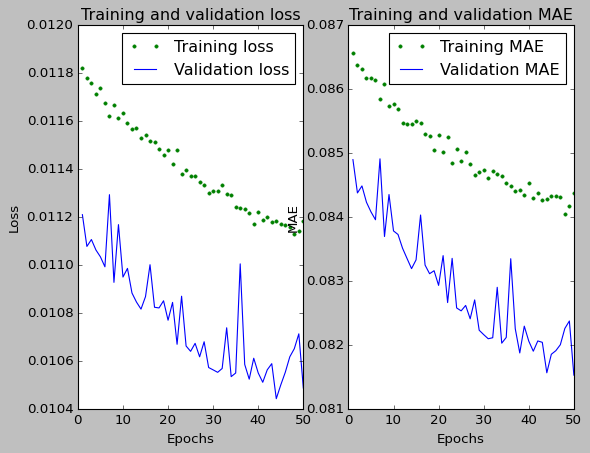

In [ ]:
# Plot the training and validation losses.
loss = history.history['loss']
val_loss = history.history['val_loss']
mae = history.history['mae']
val_mae = history.history['val_mae']

epochs = range(1, len(loss) + 1)

plt.figure()
plt.subplot(1, 2, 1)
plt.plot(epochs, loss, 'g.', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs, mae, 'g.', label='Training MAE')
plt.plot(epochs, val_mae, 'b', label='Validation MAE')
plt.title('Training and validation MAE')
plt.xlabel('Epochs')
plt.ylabel('MAE')
plt.legend()
plt.show()

#plt.tight_layout()

63/63 [==============================] - 0s 1ms/step


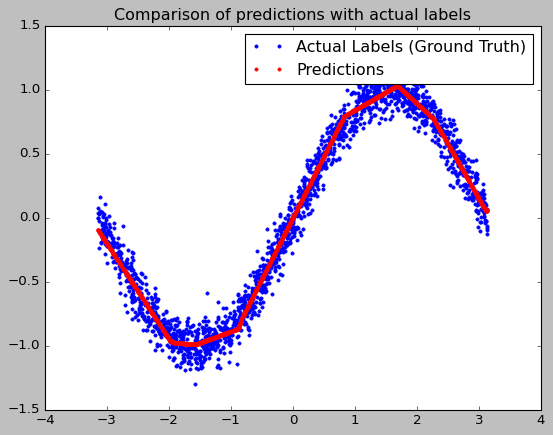

In [ ]:
# Evaluate the model on Test set
loss = model2.evaluate(X_test, y_test)
predictions = model2.predict(X_test)

# Visualize the predictions against labels
plt.clf()
plt.title('Comparison of predictions with actual labels')
plt.plot(X_test, y_test, 'b.', label='Actual Labels (Ground Truth)')
plt.plot(X_test, predictions, 'r.', label='Predictions')
plt.legend()
plt.show()


The deep model with two hidden layers (33 parameters) seems to give similar performance as the one with one hidden layer (49 parameters). 

In [ ]:
import os
MODEL_DIR = './models/'
if not os.path.exists(MODEL_DIR):
    os.mkdir(MODEL_DIR)

In [ ]:
model2.save('/content/gdrive/MyDrive/' + 'tfMdl')

In [ ]:

model2.save('/content/gdrive/MyDrive/' + 'tfMdl')

# Convert the model to the TensorFlow Lite format
converter = tf.lite.TFLiteConverter.from_keras_model(model2)
model_tflite = converter.convert()

# Save on disk
open(MODEL_DIR + 'model2.tflite', "wb").write(model_tflite)

# Quantize the model
def representative_dataset():
    for i in range(500):
        yield([X_train[i].reshape(1, 1)])
# Optimization level.
converter.optimizations = [tf.lite.Optimize.DEFAULT]
# Perform int8 quantization 
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
#Setting the following input/output type requires the input/output to be quantized manually in the inference code.
#converter.inference_input_type = tf.int8
#converter.inference_output_type = tf.int8
# Representative dataset for
converter.representative_dataset = representative_dataset
model_tflite = converter.convert()

# Save the model to disk
open(MODEL_DIR + 'model2_q.tflite', "wb").write(model_tflite)

/usr/local/lib/python3.9/dist-packages/tensorflow/lite/python/convert.py:789: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn("Statistics for quantized inputs were expected, but not "


2712

In [ ]:
model_size = os.path.getsize(MODEL_DIR + 'model2.tflite')
print("Original model size is %d bytes" % model_size)
model_size_q = os.path.getsize(MODEL_DIR + 'model2_q.tflite')
print("Quantized model size is %d bytes" % model_size_q)
difference = model_size - model_size_q
print("You saved %d bytes!" % difference)

Original model size is 2072 bytes
Quantized model size is 2712 bytes
You saved -640 bytes!


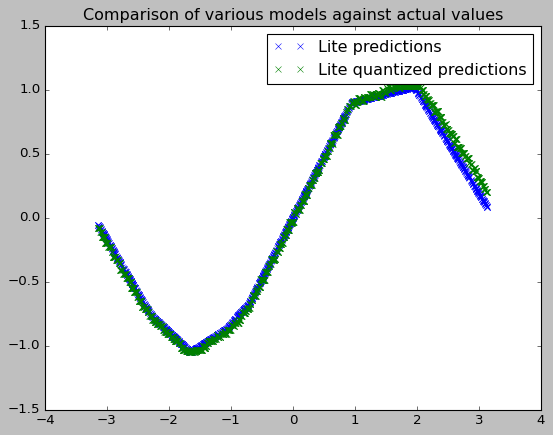

In [ ]:
# Instantiate an interpreter for each model
model = tf.lite.Interpreter(MODEL_DIR + 'model2.tflite')
model_q = tf.lite.Interpreter(MODEL_DIR + 'model2_q.tflite')

# Allocate memory for each model
model.allocate_tensors()
model_q.allocate_tensors()

# Get the input and output tensors so we can feed in values and get the results
model_input = model.tensor(model.get_input_details()[0]["index"])
model_output = model.tensor(model.get_output_details()[0]["index"])
model_q_input = model_q.tensor(model_q.get_input_details()[0]["index"])
model_q_output = model_q.tensor(model_q.get_output_details()[0]["index"])

# Create arrays to store the results
model_predictions = np.empty(X_test.size)
model_q_predictions = np.empty(X_test.size)

# Run each model's interpreter for each value and store the results in arrays
for i in range(X_test.size):
    model_input().fill(X_test[i])
    model.invoke()
    model_predictions[i] = model_output()[0]

    model_q_input().fill(X_test[i])
    model_q.invoke()
    model_q_predictions[i] = model_q_output()[0]

#error = model_predictions - model_q_predictions
# See how they line up with the data
plt.clf()
plt.title('Comparison of various models against actual values')
#plt.plot(X_test, y_test, 'bo', label='Actual values', alpha=0.4)
#plt.plot(X_test, predictions, 'ro', label='Original predictions')
plt.plot(X_test, model_predictions, 'bx', label='Lite predictions')
plt.plot(X_test, model_q_predictions, 'gx', label='Lite quantized predictions')
plt.legend()
plt.show()

In [ ]:

tf.lite.experimental.Analyzer.analyze(model_content=model_tflite)

=== TFLite ModelAnalyzer ===

Your TFLite model has '1' subgraph(s). In the subgraph description below,
T# represents the Tensor numbers. For example, in Subgraph#0, the QUANTIZE op takes
tensor #0 as input and produces tensor #7 as output.

Subgraph#0 main(T#0) -> [T#11]
  Op#0 QUANTIZE(T#0) -> [T#7]
  Op#1 FULLY_CONNECTED(T#7, T#6, T#5[7996, 3898, -4875, 6855]) -> [T#8]
  Op#2 FULLY_CONNECTED(T#8, T#4, T#3[414, 257, -758, 355]) -> [T#9]
  Op#3 FULLY_CONNECTED(T#9, T#2, T#1[-1041]) -> [T#10]
  Op#4 DEQUANTIZE(T#10) -> [T#11]

Tensors of Subgraph#0
  T#0(serving_default_dense_2_input:0) shape_signature:[-1, 1], type:FLOAT32
  T#1(sine_mlp_deep/dense_4/BiasAdd/ReadVariableOp) shape:[1], type:INT32 RO 4 bytes, buffer: 2, data:[-1041]
  T#2(sine_mlp_deep/dense_4/MatMul) shape:[1, 4], type:INT8 RO 4 bytes, buffer: 3, data:[b, H, ., .]
  T#3(sine_mlp_deep/dense_3/BiasAdd/ReadVariableOp) shape:[4], type:INT32 RO 16 bytes, buffer: 4, data:[414, 257, -758, 355]
  T#4(sine_mlp_deep/dense_3/MatM

In [ ]:
!xxd -i {MODEL_DIR + 'model2_q.tflite'} > {MODEL_DIR + 'model_q.cc'}
!xxd -i {MODEL_DIR + 'model2.tflite'} > {MODEL_DIR + 'model.cc'}

In [ ]:
!cat {MODEL_DIR + 'model.cc'}

unsigned char __models_model2_tflite[] = {
  0x1c, 0x00, 0x00, 0x00, 0x54, 0x46, 0x4c, 0x33, 0x14, 0x00, 0x20, 0x00,
  0x1c, 0x00, 0x18, 0x00, 0x14, 0x00, 0x10, 0x00, 0x0c, 0x00, 0x00, 0x00,
  0x08, 0x00, 0x04, 0x00, 0x14, 0x00, 0x00, 0x00, 0x1c, 0x00, 0x00, 0x00,
  0x94, 0x00, 0x00, 0x00, 0xec, 0x00, 0x00, 0x00, 0x84, 0x02, 0x00, 0x00,
  0x94, 0x02, 0x00, 0x00, 0xc4, 0x07, 0x00, 0x00, 0x03, 0x00, 0x00, 0x00,
  0x01, 0x00, 0x00, 0x00, 0x10, 0x00, 0x00, 0x00, 0x00, 0x00, 0x0a, 0x00,
  0x10, 0x00, 0x0c, 0x00, 0x08, 0x00, 0x04, 0x00, 0x0a, 0x00, 0x00, 0x00,
  0x0c, 0x00, 0x00, 0x00, 0x1c, 0x00, 0x00, 0x00, 0x38, 0x00, 0x00, 0x00,
  0x0f, 0x00, 0x00, 0x00, 0x73, 0x65, 0x72, 0x76, 0x69, 0x6e, 0x67, 0x5f,
  0x64, 0x65, 0x66, 0x61, 0x75, 0x6c, 0x74, 0x00, 0x01, 0x00, 0x00, 0x00,
  0x04, 0x00, 0x00, 0x00, 0x94, 0xff, 0xff, 0xff, 0x09, 0x00, 0x00, 0x00,
  0x04, 0x00, 0x00, 0x00, 0x07, 0x00, 0x00, 0x00, 0x64, 0x65, 0x6e, 0x73,
  0x65, 0x5f, 0x34, 0x00, 0x01, 0x00, 0x00, 0x00, 0x04, 0x00, 0x00, 0